# setup

In [27]:
import scMPRAforge as scm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [10]:
#load ground truth
ground_truth_mu=pd.read_csv("../../notebooks/demos/parameter_extraction_demo/synthetic_ground_truth_carp.tsv",sep="\t")
ground_truth_mu=ground_truth_mu.set_index(['cell_type','cre_id'])
ground_truth_mu.head()

true_mu
cell_type cre_id             
brain     reference         1
          mediumbody       10
          everybody       114
          redgene          30
          neurogene        99

In [4]:
from dask.distributed import Client, LocalCluster
cluster=LocalCluster()
client = Client(cluster)

# Load subsampled dataframes

In [ ]:
scmpra_data={}
inp_names=["fake_cres_v3_100.tsv","fake_cres_v3_1000.tsv","fake_cres_v3_10000.tsv"]

for name in inp_names:
    dat=scm.scMPRA_data.from_tsv("/gpfs/gibbs/pi/reilly/tabula_data/simulated/"+name)
    dat.ortho_filter()
    dat.set_negative_controls(["nobody","weak"])
    dat.set_reference_cell("liver")
    scmpra_data[name]=dat


scMPRAforge: INFO: Dropped 0 of 27 (cell_type, cre_id) combos with fewer than 3 nonzero entries.
scMPRAforge: INFO: Dropped 0 of 27 (cell_type, cre_id) combos with fewer than 3 nonzero entries.
scMPRAforge: INFO: Dropped 0 of 27 (cell_type, cre_id) combos with fewer than 3 nonzero entries.


In [8]:
models={}

for name in scmpra_data:
    model=scm.ortho()
    model.criss_cross(client=client,dat=scmpra_data[name])
    model.extract_params(client)
    models[name]=model

In [9]:
models

{'fake_cres_v3_100.tsv': <scMPRAforge.core.ortho at 0x14f17fd84bb0>,
 'fake_cres_v3_1000.tsv': <scMPRAforge.core.ortho at 0x14f17fd86e90>,
 'fake_cres_v3_10000.tsv': <scMPRAforge.core.ortho at 0x14f17f493d60>}

In [13]:
summary_df=[]
for name in models:
    working=scm.versus_truth(ground_truth_mu,models[name])
    working["type"]=name
    summary_df.append(working)

In [16]:
summary_df=pd.concat(summary_df)
summary_df

,by,mean_squared_error,mean_biased_error,mean_absolute_percent_error,type
0,cell_type,23.757070,0.085348,13.445160,fake_cres_v3_100.tsv
1,cre_id,23.813892,-0.224533,12.957325,fake_cres_v3_100.tsv
0,cell_type,4.903254,-0.019129,12.443901,fake_cres_v3_1000.tsv
1,cre_id,5.182318,-0.127739,12.023984,fake_cres_v3_1000.tsv
0,cell_type,0.508554,0.009889,10.975924,fake_cres_v3_10000.tsv
1,cre_id,0.605219,0.032495,10.534487,fake_cres_v3_10000.tsv


In [24]:
summary_df["type"]=summary_df.type.str[len("fake_cres_v3_"):-len(".tsv")]

In [25]:
summary_df

,by,mean_squared_error,mean_biased_error,mean_absolute_percent_error,type
0,cell_type,23.757070,0.085348,13.445160,100
1,cre_id,23.813892,-0.224533,12.957325,100
0,cell_type,4.903254,-0.019129,12.443901,1000
1,cre_id,5.182318,-0.127739,12.023984,1000
0,cell_type,0.508554,0.009889,10.975924,10000
1,cre_id,0.605219,0.032495,10.534487,10000


In [29]:
summary_df = summary_df.rename(columns={"type": "cells"})

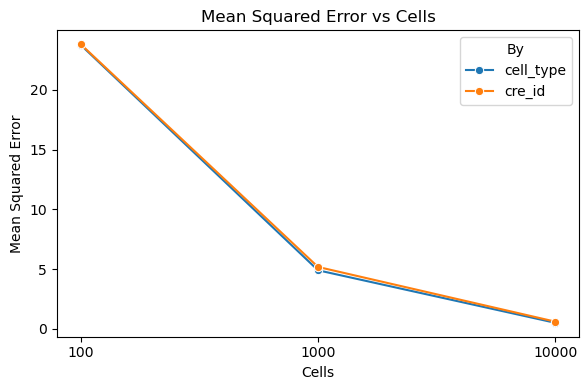

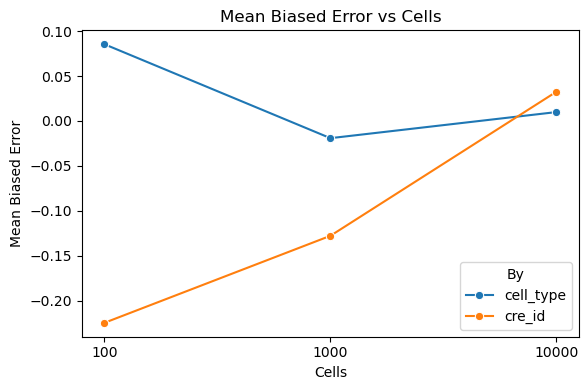

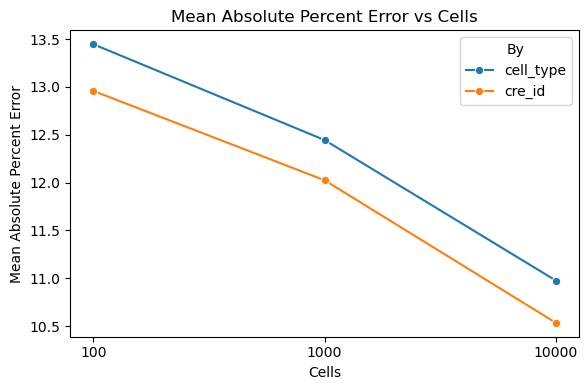

In [31]:
# Metrics to plot
metrics = [
    "mean_squared_error",
    "mean_biased_error",
    "mean_absolute_percent_error"
]

# Create a separate plot for each metric
for metric in metrics:
    plt.figure(figsize=(6, 4))
    sns.lineplot(data=summary_df, x="cells", y=metric, hue="by", marker="o")
    #plt.xscale("log")
    plt.title(f"{metric.replace('_', ' ').title()} vs Cells")
    plt.ylabel(metric.replace('_', ' ').title())
    plt.xlabel("Cells")
    plt.legend(title="By")
    plt.tight_layout()
    plt.show()

In [26]:
a=3
b=4
c=a+b